In [1]:
%load_ext watermark

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from tcspc_sim import SimSample, SimFalcon
%watermark -v -p matplotlib,numpy

Python implementation: CPython
Python version       : 3.9.2
IPython version      : 7.21.0

matplotlib: 3.3.4
numpy     : 1.20.1



In [38]:
lifetimes = [3.4, 0.8]
fractions = [25,75]
fractionnames = ['mTurq', 'darkV']
simSample = SimSample(lifetimes, fractions, fractionnames)
print(simSample)

Sample contains the following lifetimes:
  * mTurq : 3.40ns - 25.00% of photons
  * darkV : 0.80ns - 75.00% of photons


In [39]:
photons,npht = simSample.generate_photons(1e6)
simFalcon = SimFalcon(photons)
print(simFalcon)

SimFalcon with 1000000 photons.


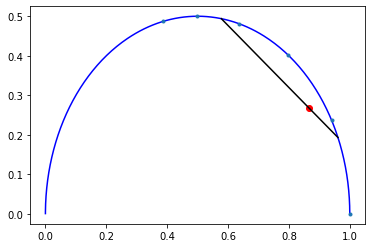

In [40]:
simFalcon.showphasor(lifetimeline=np.array((3.4, 0.8)))

In [41]:
popt = simFalcon.twocomponentfit()
intensity = [popt[0]/popt[2], popt[1]/popt[3]]
frac = intensity[0]/(intensity[0]+intensity[1])
print(f"{frac:.3} tau1 = {1/popt[1]:.3}ns ; {1-frac:.3} tau2 = {1/popt[3]:.3}ns")

0.744 tau1 = 0.795ns ; 0.256 tau2 = 3.34ns


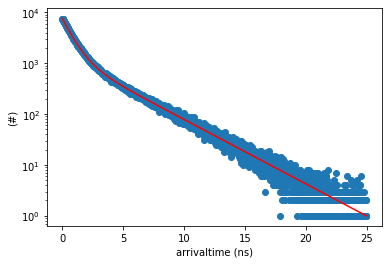

In [22]:
simFalcon.showhistogram(log=True)